In [ ]:
#instalando todos as libs
import numpy as np        
import pandas as pd       
import matplotlib.pyplot as plt 
%matplotlib inline


import nltk
from nltk.corpus import stopwords    

from wordcloud import WordCloud

nltk.download('stopwords')   
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\samue\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\samue\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
caminho = "../data/raw/spam.csv"
df = pd.read_csv(caminho, encoding='latin-1')


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [ ]:
#removendo as colunas que nao usaremos
df.drop(columns = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace = True)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   v1      5572 non-null   str  
 1   v2      5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [ ]:
#renomeando o restante das colunas
df.rename(columns = {'v1': 'target', 'v2': 'text'}, inplace = True)
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
#convertendo o target para 0 ou 1 (1=SPAM , 0=HAM)
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
#verificando valores nulos
df.isnull().sum()

target    0
text      0
dtype: int64

In [ ]:
#verificando duplicatas
df.duplicated().sum()

np.int64(403)

In [ ]:
#removendo duplicatas
df = df.drop_duplicates(keep='first')

In [ ]:
df.shape

(5169, 2)

EDA DOS DADOS

In [ ]:
#verificando a quantidade de mensagens SPAM e HAM
contagem = df['target'].value_counts()
total = contagem.sum()

porcentagem_ham = (contagem[0] /total) * 100
porcentagem_spam = (contagem[1]/ total) *100

print('percentage of 0 :' ,porcentagem_ham)
print('percentage of 1 :' ,porcentagem_spam)

In [ ]:
import matplotlib.pyplot as plt
cores = ['#FF5733', '#33FF57']
destaque = (0, 0.1)

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_facecolor('white')

fatias, rotulos, porcentagens = ax.pie(
    contagem, labels=['ham', 'spam'],
    autopct='%0.2f%%',
    startangle=90,
    colors=cores,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
    explode=destaque,  # Destaca a fatia de SPAM
    shadow=True  # Adiciona sombra
)

for rotulo, porcentagem in zip(rotulos, porcentagens):
    rotulo.set(size=14, weight='bold')
    porcentagem.set(size=14, weight='bold')

ax.set_title('Email Classification', fontsize=16, fontweight='bold')

ax.axis('equal')

plt.show()

In [ ]:
#tamanho do texto e analise da estrutura do texto
df["num_characters"] = df["text"].apply(len)
df["num_words"] = df["text"].apply(lambda x: len(nltk.word_tokenize(x)))
df["num_sentence"] = df["text"].apply(lambda x: len(nltk.sent_tokenize(x)))

In [ ]:
df[['num_characters', 'num_words', 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.460437,1.965564
std,58.236293,13.334441,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
#HAM
df[df['target'] == 0][['num_characters', 'num_words', 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.128432,1.820195
std,56.358207,13.504730,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
#SPAM
df[df['target'] == 1][['num_characters', 'num_words', 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.672282,2.970904
std,30.137753,7.010932,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


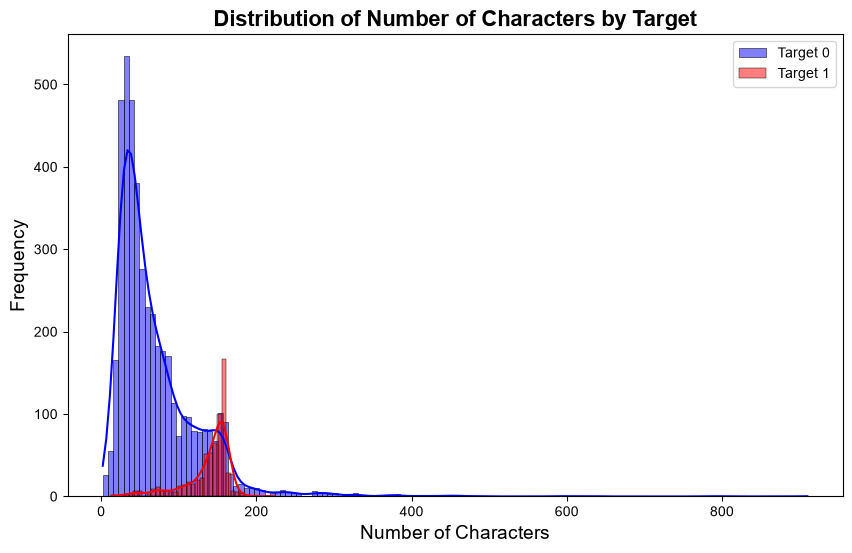

In [ ]:
#Distribuição do tamanho do texto (número de caracteres) para mensagens HAM e SPAM
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.histplot(df[df['target'] == 0]['num_characters'], color='blue', label='Target 0', kde=True)

sns.histplot(df[df['target'] == 1]['num_characters'], color='red', label='Target 1', kde=True)


plt.xlabel('Number of Characters', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Distribution of Number of Characters by Target', fontsize=16, fontweight='bold')

plt.legend()

sns.set(style='whitegrid')

plt.show()

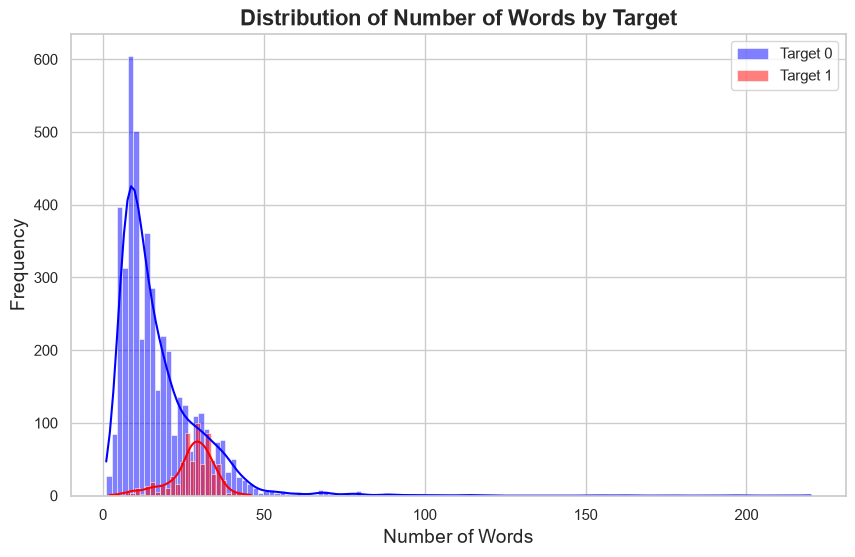

In [ ]:
#Distribuição do valor do número de palavras para mensagens HAM e SPAM
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.histplot(df[df['target'] == 0]['num_words'], color='blue', label='Target 0', kde=True)

sns.histplot(df[df['target'] == 1]['num_words'], color='red', label='Target 1', kde=True)

plt.xlabel('Number of Words', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Distribution of Number of Words by Target', fontsize=16, fontweight='bold')

plt.legend()

sns.set(style='whitegrid') 

plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pairplot: cruza cada par de variáveis, colorindo por classe (HAM/SPAM)
sns.set(style='ticks', color_codes=True)
g = sns.pairplot(df, hue='target', diag_kind='kde', markers=["o", "s"])

# Título do gráfico
g.fig.suptitle("Pairplot of Data by Target", fontsize=16, fontweight='bold')
plt.subplots_adjust(top=0.95)  # Evita que o título sobreponha os gráficos

# Personaliza a legenda
g._legend.set_title('Target')
for t, l in zip(g._legend.texts, ["Target 0", "Target 1"]):
    t.set_text(l)

plt.show()

In [ ]:
df[['target','num_characters', 'num_words', 'num_sentence']].corr()

,target,num_characters,num_words,num_sentence
target,1.000000,0.384717,0.262720,0.263939
num_characters,0.384717,1.000000,0.965686,0.624139
num_words,0.262720,0.965686,1.000000,0.679767
num_sentence,0.263939,0.624139,0.679767,1.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de correlação (-1 a 1: quanto mais perto de 1, mais forte a relação)
matriz_correlacao = df[['target', 'num_characters', 'num_words', 'num_sentence']].corr()

# Mapa de calor com os valores escritos em cada quadrado
plt.figure(figsize=(10, 6))
sns.set(font_scale=1.2)  # Aumenta a fonte
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")

plt.title("Correlation Heatmap", fontsize=16, fontweight='bold')

# Rotaciona os rótulos do eixo X para não sobreporem
plt.xticks(rotation=45)

plt.show()

In [ ]:
# Stemmer: reduz a palavra ao radical (ex.: "running" -> "run")
from nltk.stem.porter import PorterStemmer

# Módulo com a lista de pontuações
import string

ps = PorterStemmer()

# Limpa o texto para ser usado pelos modelos
def transformar_texto(texto):
    # 1) Deixa tudo em minúsculas
    texto = texto.lower()
    
    # 2) Quebra o texto em palavras (tokens)
    texto = nltk.word_tokenize(texto)
    
    # 3) Mantém só letras e números
    tokens = []
    for palavra in texto:
        if palavra.isalnum():
            tokens.append(palavra)
            
    texto = tokens[:]
    tokens.clear()
    
    # 4) Remove stopwords ("the", "is"...) e pontuação
    for palavra in texto:
        if palavra not in stopwords.words('english') and palavra not in string.punctuation:
            tokens.append(palavra)
        
    # 5) Reduz cada palavra ao radical
    texto = tokens[:]
    tokens.clear()
    for palavra in texto:
        tokens.append(ps.stem(palavra))
    
    # 6) Junta as palavras de volta em uma string
    return " ".join(tokens)

In [ ]:
transformar_texto('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...')

In [ ]:
df['transformed_text'] = df['text'].apply(transformar_texto)

In [ ]:
nuvem = WordCloud(width = 500, height = 500, min_font_size = 10, background_color = 'white')
nuvem_spam = nuvem.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep = " "))
plt.figure(figsize = (15,6))
plt.imshow(nuvem_spam)
plt.show()

In [ ]:
nuvem_ham = nuvem.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep = " "))
plt.figure(figsize = (15,6))
plt.imshow(nuvem_ham)
plt.show()

In [ ]:
#encontrando as 30 palavras mais comuns em mensagens SPAM
palavras_spam = []
for frase in df[df['target'] == 1]['transformed_text'].tolist():
    for palavra in frase.split():
        palavras_spam.append(palavra)

In [ ]:
from collections import Counter
top_spam_df = pd.DataFrame(Counter(palavras_spam).most_common(30))

In [ ]:
sns.barplot(data = top_spam_df, x = top_spam_df[0], y = top_spam_df[1], palette = 'bright')
plt.xticks(rotation = 90)
plt.show()

In [ ]:
#encontrando as 30 palavras mais comuns em mensagens HAM
palavras_ham = []
for frase in df[df['target'] == 0]['transformed_text'].tolist():
    for palavra in frase.split():
        palavras_ham.append(palavra)

In [ ]:
top_ham_df = pd.DataFrame(Counter(palavras_spam).most_common(30))

In [ ]:
sns.barplot(data = top_ham_df, x = top_ham_df[0], y = top_ham_df[1], palette = 'cool')
plt.xticks(rotation = 90)
plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfid = TfidfVectorizer(max_features = 3000)

In [ ]:
X = tfid.fit_transform(df['transformed_text']).toarray()
y = df['target'].values

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test , y_train, y_test = train_test_split(X,y,test_size = 0.20, random_state = 2)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier


In [ ]:
svc = SVC(kernel= "sigmoid", gamma  = 1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth = 5)
lrc = LogisticRegression(solver = 'liblinear', penalty = 'l1')
rfc = RandomForestClassifier(n_estimators = 50, random_state = 2 )
abc = AdaBoostClassifier(n_estimators = 50, random_state = 2)
bc = BaggingClassifier(n_estimators = 50, random_state = 2)
etc = ExtraTreesClassifier(n_estimators = 50, random_state = 2)
gbdt = GradientBoostingClassifier(n_estimators = 50, random_state = 2)   

In [ ]:
modelos = {
    'SVC': svc,
    'KNN': knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'Adaboost': abc,
    'Bgc': bc,
    'ETC': etc,
    'GBDT': gbdt
}

In [ ]:
from sklearn.metrics import accuracy_score, precision_score
def treinar_modelo(modelo, X_train, y_train, X_test, y_test):
    modelo.fit(X_train,y_train)
    y_pred = modelo.predict(X_test)
    acuracia = accuracy_score(y_test, y_pred)
    precisao = precision_score(y_test, y_pred)
    return acuracia , precisao

In [ ]:
acuracias = []
precisoes = []
for nome , modelo in modelos.items():
    acuracia_atual, precisao_atual = treinar_modelo(modelo, X_train, y_train, X_test, y_test)
    print()
    print("For: ", nome)
    print("Accuracy: ", acuracia_atual)
    print("Precision: ", precisao_atual)
    
    acuracias.append(acuracia_atual)
    precisoes.append(precisao_atual)

## Conclusão

- **SVC** e **Random Forest** tiveram as maiores acurácias (~97,58%).
- **Naive Bayes** teve precisão de 100% (nenhum falso positivo, ou seja, nenhuma mensagem legítima marcada como SPAM).
- **Gradient Boosting**, **AdaBoost**, **Regressão Logística** e **Bagging** também foram bem, com acurácias entre 94,68% e 96,03%.